XGBOOST - Week - Quantile

## 1. Imports

In [59]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des données
Lecture du fichier CSV contenant les relevés piézométriques du piézomètre Bourdet.

In [60]:
from hydrosense.database.bigquery import load_piezo_bq
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense import params

In [97]:
DATA_CODE_PIEZO = "BSS001PHQG" #"BSS001GNWX" #  "BSS001QSMT" #BSS001QHYH"

In [98]:
df = clean_piezo(load_piezo_bq(DATA_CODE_PIEZO))

BSS001PHQG : 13682 lignes chargées
Trou de 292 jours détecté ! 5081 lignes supprimées.
DataFrame final : 2002-06-17 00:00:00 → 2026-05-30 00:00:00 | 8749 jours


### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

> **Pourquoi ?** Les méthodes de séries temporelles comme `resample()` nécessitent
> un index de type `DatetimeIndex`. En définissant la date comme index, on peut
> ensuite rééchantillonner, découper et aligner les données par date facilement.

In [99]:
# Vérifie que la colonne date_mesure est bien présente (pas encore en index)
if 'date_mesure' in df.columns:
    df.set_index('date_mesure', inplace=True)

# S'assure que l'index est bien de type DatetimeIndex
df.index = pd.to_datetime(df.index)

df.head()

,niveau_nappe_eau
date_mesure,
2002-06-17,36.98
2002-06-18,36.98
2002-06-19,36.97
2002-06-20,37.03
2002-06-21,37.03


### Rééchantillonnage mensuel & découpage Train/Test

Les données brutes sont journalières. On les agrège à la **maille mensuelle** (moyenne) pour :
- Réduire le bruit quotidien
- Aligner avec les modèles hydrologiques saisonniers

Le **split Train/Test** isole les **12 derniers mois** (juin 2025 → mai 2026) comme jeu de validation.
Le modèle ne voit jamais ces données pendant l'entraînement — c'est ce qui garantit une évaluation honnête.

In [64]:
!pip install xgboost

## 5. XGBoost — Gradient Boosting

**XGBoost** est un algorithme de *gradient boosting* : il construit des arbres de décision
en séquence, chaque arbre corrigeant les erreurs du précédent.

Il surpasse souvent le Random Forest sur les séries temporelles car il est plus sensible
aux **relations non-linéaires** et aux **interactions entre features**.

La grille de paramètres testés :
- `n_estimators` : nombre d'arbres
- `learning_rate` : vitesse d'apprentissage (trop élevé = overfitting)
- `max_depth` : profondeur max de chaque arbre
- `subsample` / `colsample_bytree` : régularisation par sous-échantillonnage

In [100]:
# 'ME' = Month End (anciennement 'M', déprécié depuis pandas 2.2)
y_week = df["niveau_nappe_eau"].resample('W').mean()
y_week

date_mesure
2002-06-23    37.005714
2002-06-30    36.968571
2002-07-07    37.058571
2002-07-14    37.028571
2002-07-21    36.984286
                ...    
2026-05-03    37.364286
2026-05-10    37.355714
2026-05-17    37.240000
2026-05-24    37.152857
2026-05-31    37.041667
Freq: W-SUN, Name: niveau_nappe_eau, Length: 1250, dtype: float64

In [101]:
# 1. Préparation des colonnes (Lag)
df_w = pd.DataFrame(y_week)
df_w['semaine'] = df_w.index.isocalendar().week
df_w['lag_1'] = df_w['niveau_nappe_eau'].shift(1)
df_w['lag_2'] = df_w['niveau_nappe_eau'].shift(2)
df_w['lag_3'] = df_w['niveau_nappe_eau'].shift(3)
df_w['lag_4'] = df_w['niveau_nappe_eau'].shift(4)
df_w['lag_52'] = df_w['niveau_nappe_eau'].shift(52)


In [102]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_w['moyenne_3w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_w['moyenne_6w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=6).mean()

In [103]:

# ══════════════════════════════════════════════════════════════════════════════
# 3. CALCUL DES PERCENTILES (Sur l'historique complet, juste ICI !)
# ══════════════════════════════════════════════════════════════════════════════
# On regroupe par SEMAINE (de 1 à 52) pour avoir les seuils spécifiques à chaque période de l'année
seuils_hebdo = df_w.groupby('semaine').agg(
    P95=('niveau_nappe_eau', lambda x: x.quantile(0.95)),
    P85=('niveau_nappe_eau', lambda x: x.quantile(0.85)),
    P50=('niveau_nappe_eau', lambda x: x.quantile(0.50)),
    P20=('niveau_nappe_eau', lambda x: x.quantile(0.20)),
    P10=('niveau_nappe_eau', lambda x: x.quantile(0.10)),
    P5 =('niveau_nappe_eau', lambda x: x.quantile(0.05))
).to_dict(orient='index')


In [104]:
# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_w = df_w.dropna()

X = df_w[['semaine', 'lag_1', 'lag_2', 'lag_3','lag_4', 'lag_52', 'moyenne_3w', 'moyenne_6w']]

y_target = df_w['niveau_nappe_eau']

# Split Train / Test
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [105]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.8, 1.0]
}


# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)


Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


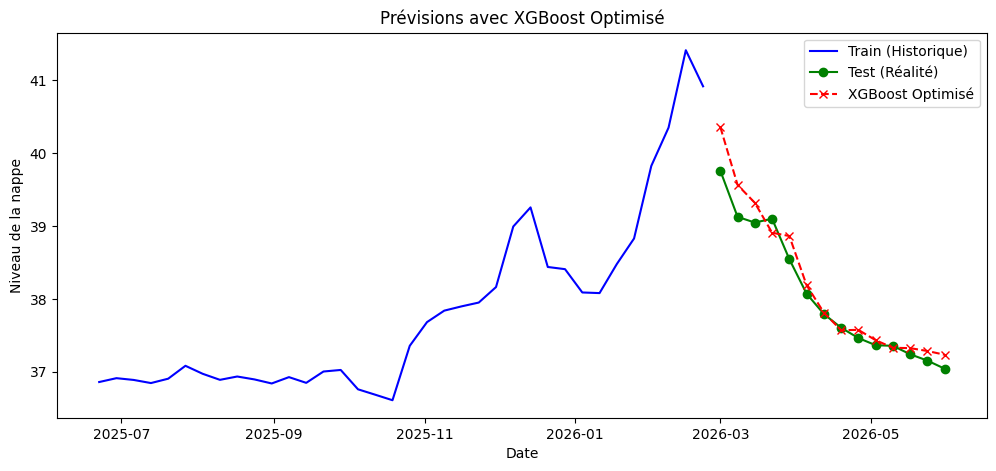

In [106]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

In [107]:
# Calcul des percentiles sur tout l'historique d'un coup (valeurs fixes)
p95_global = df_w['niveau_nappe_eau'].quantile(0.95)
p85_global = df_w['niveau_nappe_eau'].quantile(0.85)
p50_global = df_w['niveau_nappe_eau'].quantile(0.50)
p20_global = df_w['niveau_nappe_eau'].quantile(0.20)
p10_global = df_w['niveau_nappe_eau'].quantile(0.10)
p5_global  = df_w['niveau_nappe_eau'].quantile(0.05)

In [117]:
p5_global


np.float64(36.242642857142854)

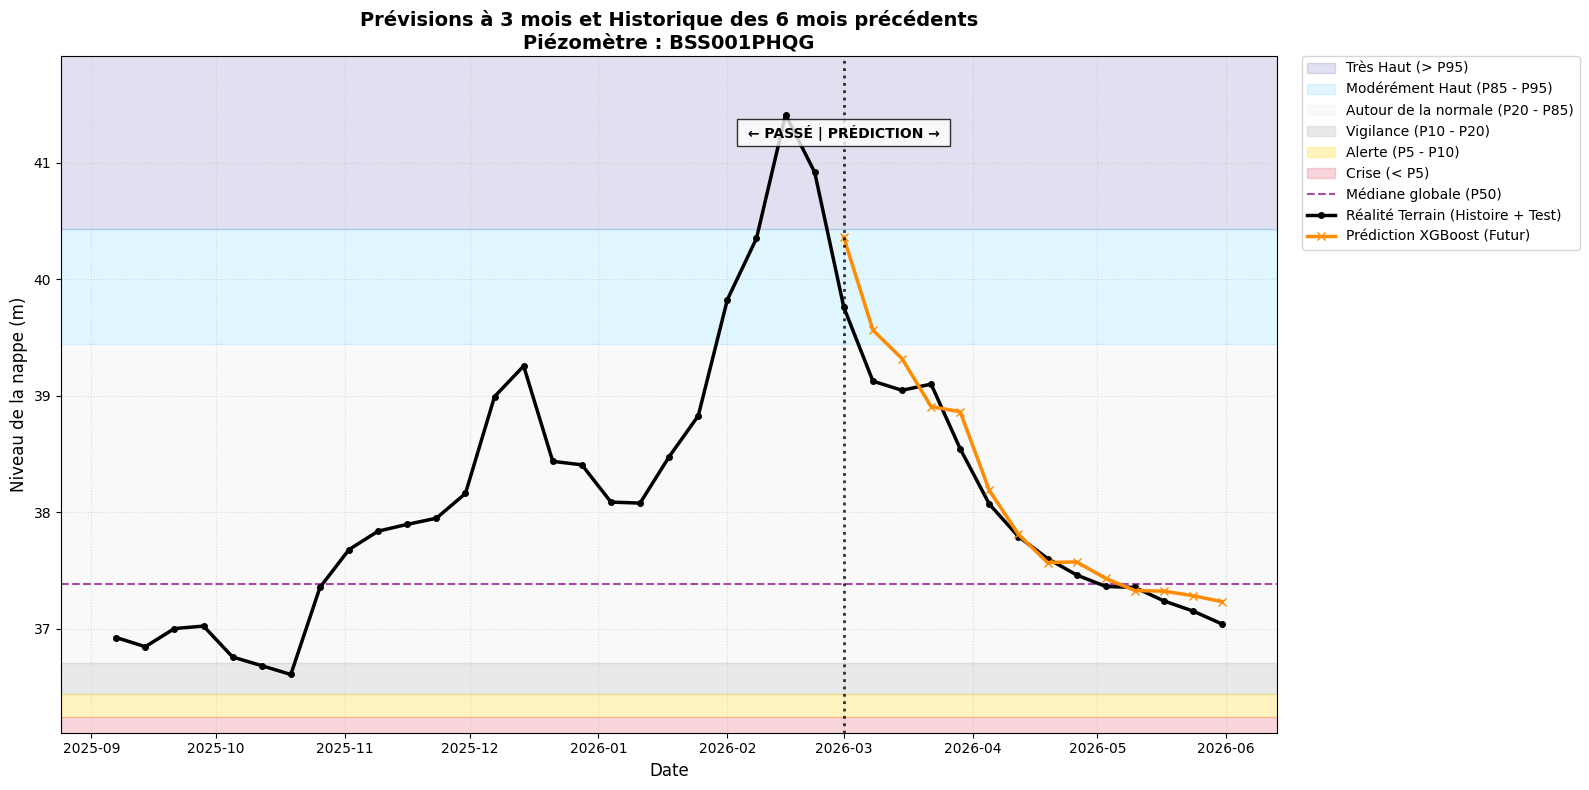

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. RÉCUPÉRATION DES 6 MOIS PRÉCÉDENTS
# ══════════════════════════════════════════════════════════════════════════════

# On définit la date de début (6 mois avant le début du test qui commence le 2026-03-01)
# 6 mois avant mars 2026 -> septembre 2025
date_debut_historique = '2025-09-01'

# On extrait l'historique réel depuis y_train
y_historique_6m = y_train.loc[date_debut_historique:]

# On fusionne l'historique des 6 mois et la réalité du test pour avoir la courbe noire complète
y_reel_complet = pd.concat([y_historique_6m, y_test])


# ══════════════════════════════════════════════════════════════════════════════
# 2. PRÉPARATION DU GRAPHIQUE
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(16, 8))

# Bornes dynamiques basées sur le signal complet pour caler les bandes de couleur
ymin, ymax = y_reel_complet.min() - 2, y_reel_complet.max() + 2


# ══════════════════════════════════════════════════════════════════════════════
# 3. TRACÉ DES BANDES HORIZONTALES (axhspan s'étend sur tout l'axe X automatiquement)
# ══════════════════════════════════════════════════════════════════════════════
plt.axhspan(p95_global, ymax, color='darkblue', alpha=0.12, label='Très Haut (> P95)')
plt.axhspan(p85_global, p95_global, color='deepskyblue', alpha=0.12, label='Modérément Haut (P85 - P95)')
plt.axhspan(p20_global, p85_global, color='gainsboro', alpha=0.15, label='Autour de la normale (P20 - P85)')
plt.axhspan(p10_global, p20_global, color='darkgray', alpha=0.25, label='Vigilance (P10 - P20)')
plt.axhspan(p5_global, p10_global, color='gold', alpha=0.25, label='Alerte (P5 - P10)')
plt.axhspan(ymin, p5_global, color='crimson', alpha=0.18, label='Crise (< P5)')

# Ligne droite pour la Médiane (P50)
plt.axhline(y=p50_global, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label='Médiane globale (P50)')


# ══════════════════════════════════════════════════════════════════════════════
# 4. TRACÉ DES COURBES (Réalité vs Prédiction)
# ══════════════════════════════════════════════════════════════════════════════

# A. La réalité terrain : on trace la courbe COMPLETE (6 mois d'histoire + 3 mois de test)
plt.plot(y_reel_complet.index, y_reel_complet, label='Réalité Terrain (Histoire + Test)', color='black', marker='o', linewidth=2.5, markersize=4)

# B. La prédiction XGBoost : elle ne commence QU'À LA DATE DU TEST
# On utilise l'index de y_test pour qu'elle se positionne pile au bon endroit à droite du graphique
plt.plot(y_test.index, forecast_xgb_opt, label='Prédiction XGBoost (Futur)', color='darkorange', linestyle='-', marker='x', linewidth=2.5, markersize=6)

# C. Optionnel : Ajout d'une ligne verticale pointillée pour séparer le Passé du Futur
plt.axvline(x=y_test.index[0], color='black', linestyle=':', linewidth=2, alpha=0.8)
plt.text(y_test.index[0], y_reel_complet.max() - 0.2, ' ← PASSÉ | PRÉDICTION → ', fontsize=10, fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8))


# ══════════════════════════════════════════════════════════════════════════════
# 5. CONFIGURATION VISUELLE
# ══════════════════════════════════════════════════════════════════════════════
plt.title(f"Prévisions à 3 mois et Historique des 6 mois précédents\nPiézomètre : {DATA_CODE_PIEZO}", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Niveau de la nappe (m)", fontsize=12)

# Ajustement des axes Y pour englober tout le signal proprement
plt.ylim(y_reel_complet.min() - 0.5, y_reel_complet.max() + 0.5)

# Légende à droite
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., facecolor='white')

plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()

plt.show()